# Comet case - Laminar vs. turbulent - 2D



Power spectral density in 1D, independent of the domain size:

$\mathrm{PSD} = \Delta x/N \cdot |\hat{y}|^2 = \Delta x/N \cdot |\mathrm{dft}(y)|^2$

In 2D, using a 2D discrete fourier transform:

$\mathrm{PSD} = \Delta x^2/(N_x\cdot N_y) \cdot |\hat{y}|^2 = \Delta x/N \cdot |\mathrm{dft}_{2d}(y)|^2$

PSD is now a 2D array. Using the following from the litterature:

$PSD_{omni} = \sum_{v_{perp}} PSD$

two sub_domain of different sizes will have different powers. Not satisfactory.

In [1]:
from menura_utils import *
import own_tools as oT
import own_colours as oC

import scipy.stats
from scipy.fftpack import fft, fft2

In [2]:
idx_it = 10000
path = '../Data/run_015'
md_inj = menura_data(path, '', idx_it, ask_scp=False)

idx_it = 6000
path = '../Data/run_016'
md = menura_data(path, '', idx_it, ask_scp=False)


._____________________________________________________________________________________
| Physical run parameters:
|    
| 4 processes.
|
| Dimensionality:                  2D 
|
| B_0:                              2.50e-09 T
| n_0:                              1.00e+06 m^-3
| T_eon:                            1.80e+05 K
| T_ion:                            1.80e+05 K
|
| Proton plasma frequency:         1316.5700 rad/s
| Proton gyrofrequency:               0.2394 rad/s
| Electron plasma frequency:       5.6422e+04 rad/s
| Electron gyrofrequency:           439.6750 rad/s
|
| Proton inertial length d_i :      227.7080 km
| Electron inertial length d_e :      5.3134 km
| Debye length lambda_D :             0.0293 km
| Gyro-radius (v_th) :                1.0000
|
| Alfven speed :                     54.5161 km/s
| Sound speed :                      77.0973 km/s
| Magnetosonic speed :               94.4246 km/s
| Ion thermal speed :                54.5161 km/s
| Electron thermal speed :    

In [3]:
def plt_field_2d_sub_spectrum(menura_data, field_label='Bx', sub=[[10, 20], [10, 20]]):

        '''if field_label=='Bx':
            field = menura_data.recompose_field(menura_data.B[:, 0])
        elif field_label=='B_perp_sqr':
            field_x = menura_data.recompose_field(menura_data.B[:, 0])
            field_y = menura_data.recompose_field(menura_data.B[:, 1])
            field = field_x**2 + field_y**2
        elif field_label=='E_perp_sqr':
            field_x = menura_data.recompose_field(menura_data.E[:, 0])
            field_y = menura_data.recompose_field(menura_data.E[:, 1])
            field = field_x**2 + field_y**2
        elif field_label=='ui_perp_sqr':
            field_x = menura_data.recompose_field(menura_data.curr[:, 0]/menura_data.dens)
            field_y = menura_data.recompose_field(menura_data.curr[:, 1]/menura_data.dens)
            field = field_x**2 + field_y**2'''

            
            
            
            
        len_x = sub[0][1] - sub[0][0]
        len_y = sub[1][1] - sub[1][0]
        dx = menura_data.mp.dX
        #
        f_x = np.fft.fftshift(np.fft.fftfreq(len_x, d=dx))
        f_y = np.fft.fftshift(np.fft.fftfreq(len_y, d=dx))
        f2d = np.ones((len_x, len_y))
        f2d = np.sqrt(f_x[:,None]**2+f_y[None,:]**2)
        ##
        bin_edges = np.linspace(f_x[0], f_x[-1], 1000)
        ##
        bin_centres = .5*(bin_edges[1:]+bin_edges[:-1])
        bin_centres *= 2*np.pi  ## From spatial frequency to k
        # bin_centers *= d_p
        field_x = menura_data.recompose_field(menura_data.B[:, 0])
        field_y = menura_data.recompose_field(menura_data.B[:, 1])
        field = field_x**2 + field_y**2
      
        PSD = np.fft.fftshift(fft2(field[sub[0][0]:sub[0][1], sub[1][0]:sub[1][1]]))
        PSD = 2.*dx**2/(len_x*len_y) * np.abs(PSD)**2
        spectrum, bin_edges, fff = scipy.stats.binned_statistic(f2d.flatten(), PSD.flatten(), statistic='sum', bins=bin_edges)
        
        #np.save('bite_tmp.npy', {'spectrum': spectrum, 'bin_centres': bin_centres})
        dicdic = np.load('bite_tmp.npy', allow_pickle=True).item()
    
            
            
        fig, AX = plt.subplots(1, 2, figsize=(20,10))
        AX[0].set_aspect('equal')

        # AX[0].pcolormesh(xGrid, yGrid, bPerp.T, cmap='RdBu_r', rasterized=True)
        AX[0].imshow(np.log10(np.sqrt(field)).T,
                    vmin = -1.5, vmax = 1.,
                    extent=(0., menura_data.mp.len_x_cst*menura_data.mp.dX, 0., menura_data.mp.len_y_cst*menura_data.nb_proc*menura_data.mp.dX),
                    interpolation='bilinear',
                    rasterized=True, cmap=oC.bwr_2, origin='lower')
        # AX[1].pcolormesh(f, f, np.log10(PSDB).T, cmap='RdBu_r')#, vmin = 0, vmax = 10000)
        
        AX[0].plot([md.grid_x_box[sub[0][0]], md.grid_x_box[sub[0][0]], md.grid_x_box[sub[0][1]], md.grid_x_box[sub[0][1]], md.grid_x_box[sub[0][0]]],
                    [md.grid_y_box[sub[1][0]], md.grid_y_box[sub[1][1]], md.grid_y_box[sub[1][1]], md.grid_y_box[sub[1][0]], md.grid_y_box[sub[1][0]]],
                    c='r')

        
        dic = np.load(f'../Data/run_015/spectra.npy', allow_pickle=True).item()
        # AX[1].plot(f2d.flatten()*2*np.pi*d_p, PSDB.flatten(), '+', alpha=.1, rasterized=True)
        x, y = oT.logSlidingWindow(bin_centres, spectrum, halfWidth=.05)
        AX[1].plot(x, y,  label='sub PSD',  c=oC.rgb[0])
        #AX[1].plot(dic['bin_centres'], dic['B_perp_sqr'],  label='B_perp_sqr_0',  c='k', lw=1)
        
        x, y = oT.logSlidingWindow(dicdic['bin_centres'], dicdic['spectrum'], halfWidth=.05)
        AX[1].plot(x, y*50,  label='sub PSD tmp',  c=oC.rgb[1])

        x = np.array([2e-1, 2e0])
        y = x**(-5/3) * 3.8e-1
        x = np.array([2e-1, 2e0])
        y3 = x**(-3/2) * 1.e-1
        # x2 = np.array([2e0, 3e0])
        # y2 = x2**(-2.8) * 3.2e-1
        #AX[1].plot(x, y, 'k', lw=1)
        #AX[1].plot(x, y3, 'k', lw=1)
        # AX[1].plot(x2, y2, '--b')

        AX[1].set_xlabel('k d_i')
        AX[1].set_xscale('log')
        AX[1].set_yscale('log')
        # AX[1].set_ylim([2.4e-2,24.])
        AX[1].set_xlim([.1, 10])

        plt.legend()
        oT.set_spines(AX)
        plt.tight_layout()
        plt.show()

0.0 0.5 0.5 0.0 0.5 0.5

Plot omni_directional spectrum.

0.0 0.5 0.5 0.0 0.5 0.5
yea


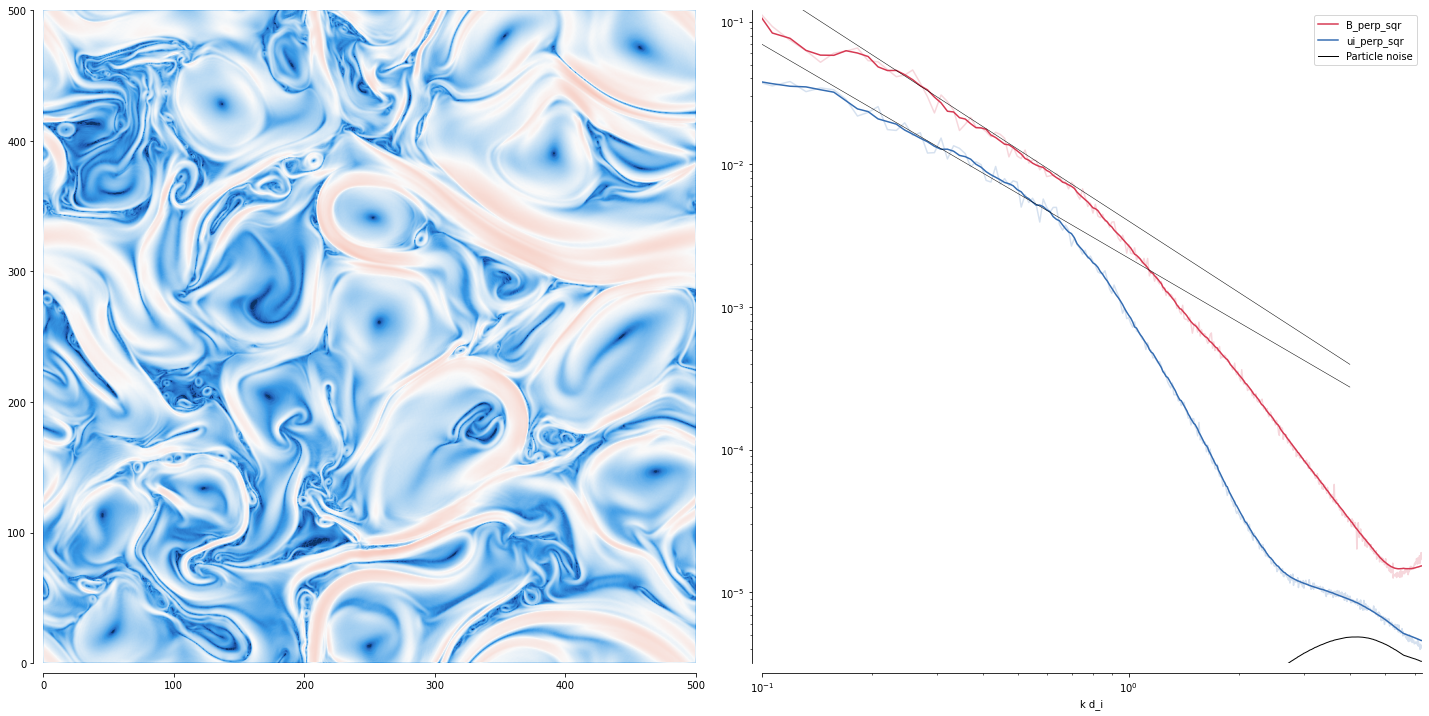

In [4]:
md_inj.produce_spectra()
md_inj.plt_field_2d_spectrum('B_perp_sqr')

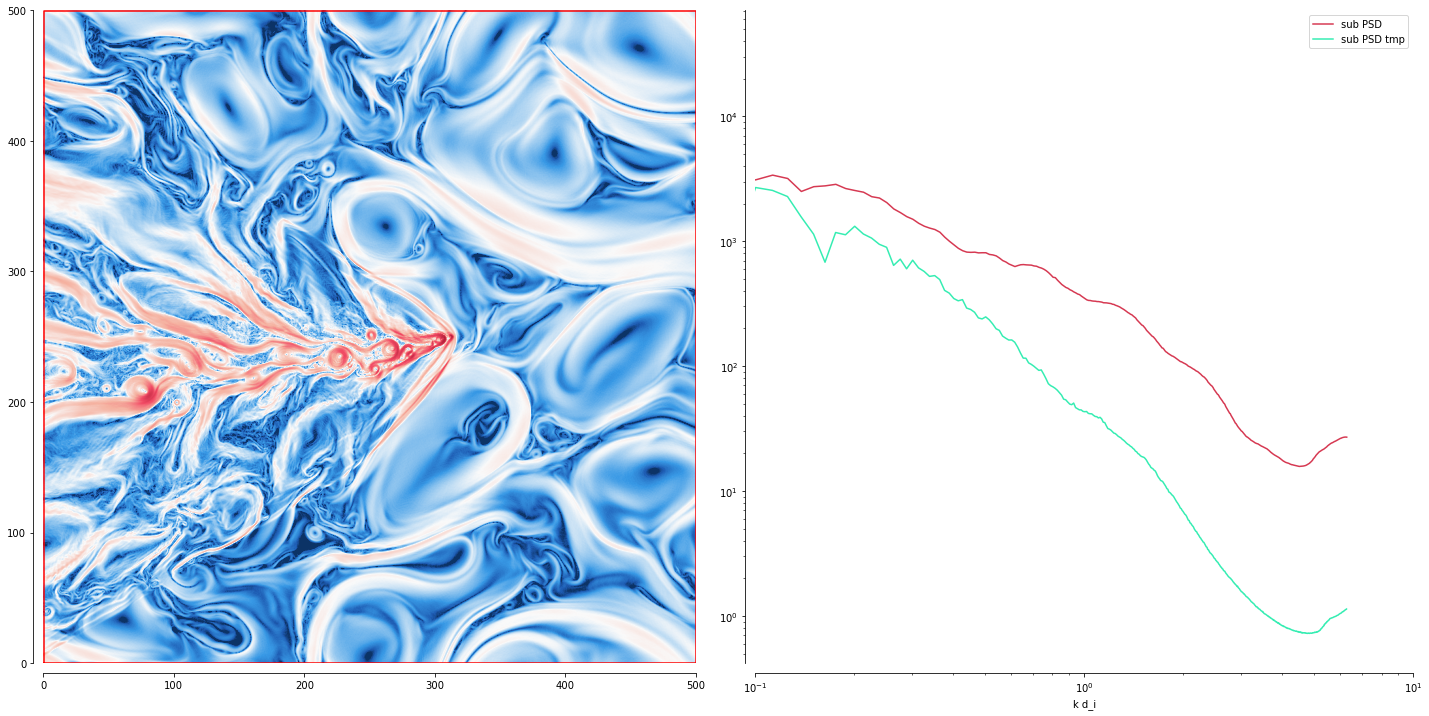

In [5]:
plt_field_2d_sub_spectrum(md, field_label='B_perp_sqr', sub=[[0, 999], [0, 999]])

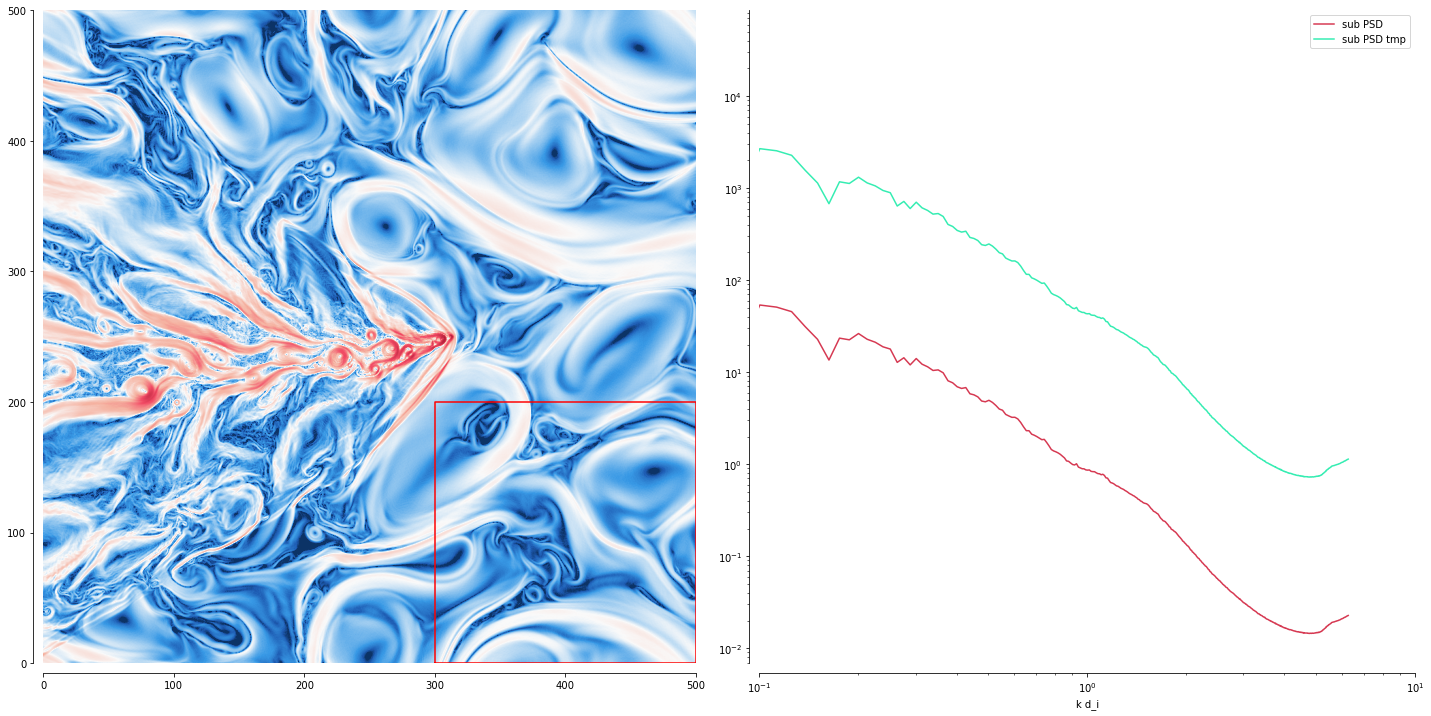

In [6]:
#md.produce_spectra()
plt_field_2d_sub_spectrum(md, field_label='B_perp_sqr', sub=[[600, 999], [0, 400]])

0.0 0.5 0.5 0.0 0.5 0.5


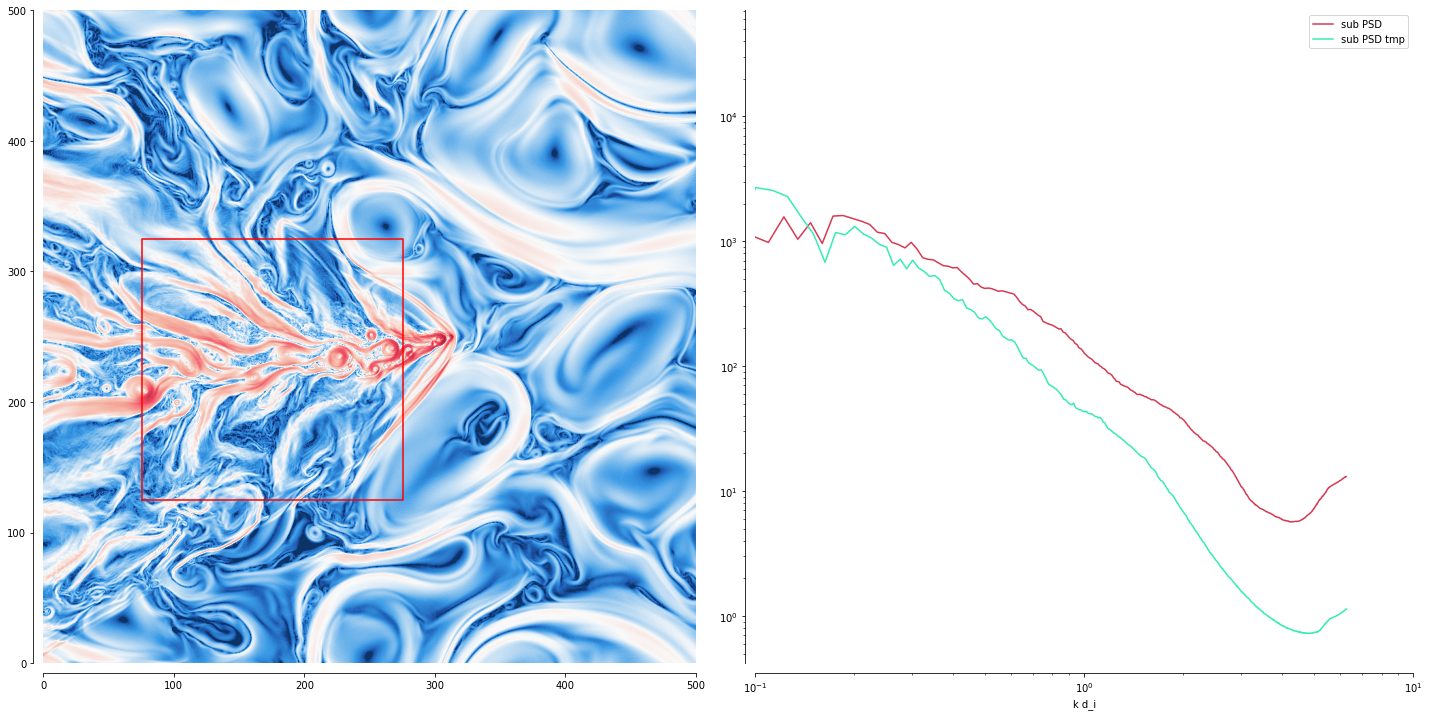

In [7]:
md.produce_spectra()
plt_field_2d_sub_spectrum(md, field_label='B_perp_sqr', sub=[[150, 550], [250, 650]])

In [9]:
idx_it = 10000
path = '../Data/run_015'
md_inj = menura_data(path, '', idx_it, ask_scp=False)


._____________________________________________________________________________________
| Physical run parameters:
|    
| 4 processes.
|
| Dimensionality:                  2D 
|
| B_0:                              2.50e-09 T
| n_0:                              1.00e+06 m^-3
| T_eon:                            1.80e+05 K
| T_ion:                            1.80e+05 K
|
| Proton plasma frequency:         1316.5700 rad/s
| Proton gyrofrequency:               0.2394 rad/s
| Electron plasma frequency:       5.6422e+04 rad/s
| Electron gyrofrequency:           439.6750 rad/s
|
| Proton inertial length d_i :      227.7080 km
| Electron inertial length d_e :      5.3134 km
| Debye length lambda_D :             0.0293 km
| Gyro-radius (v_th) :                1.0000
|
| Alfven speed :                     54.5161 km/s
| Sound speed :                      77.0973 km/s
| Magnetosonic speed :               94.4246 km/s
| Ion thermal speed :                54.5161 km/s
| Electron thermal speed :    

0.0 0.5 0.5 0.0 0.5 0.5

Plot omni_directional spectrum.

0.0 0.5 0.5 0.0 0.5 0.5
yea


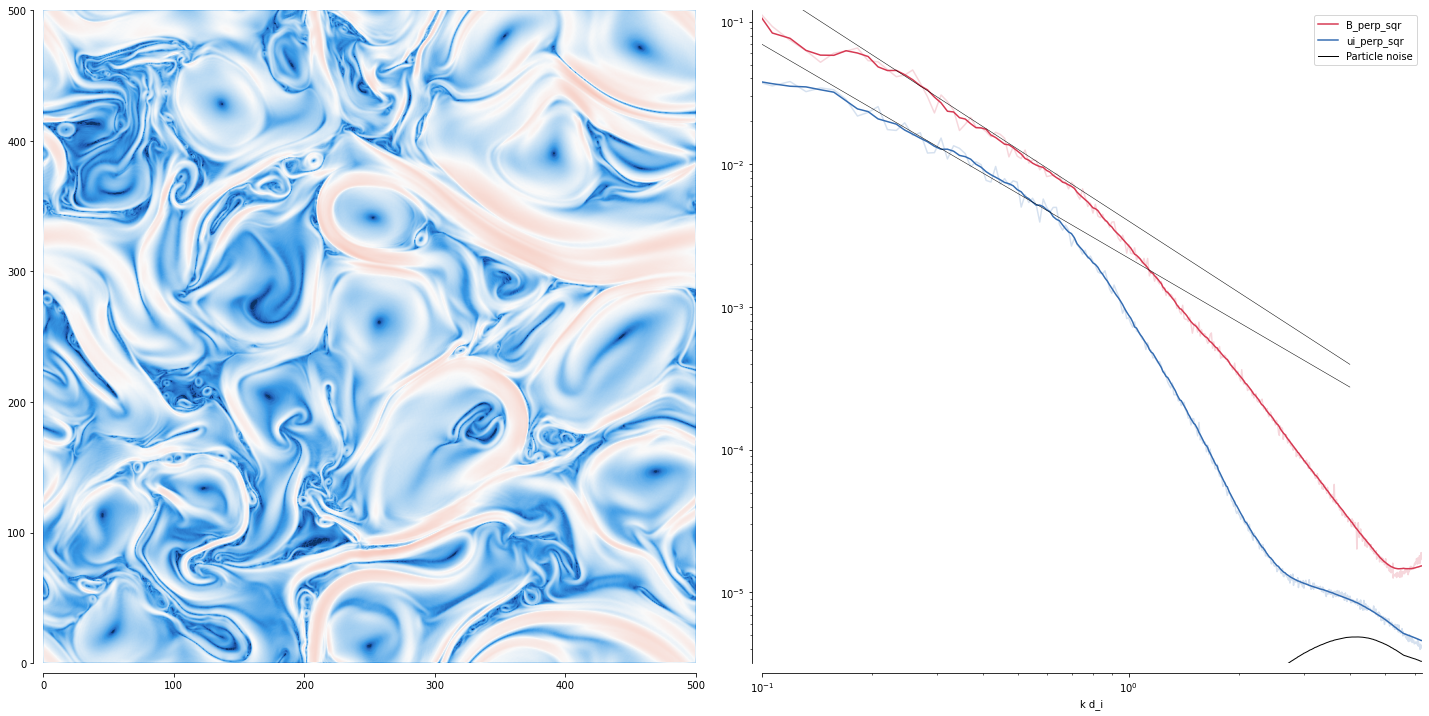

In [10]:
md_inj.produce_spectra()
md_inj.plt_field_2d_spectrum('B_perp_sqr')

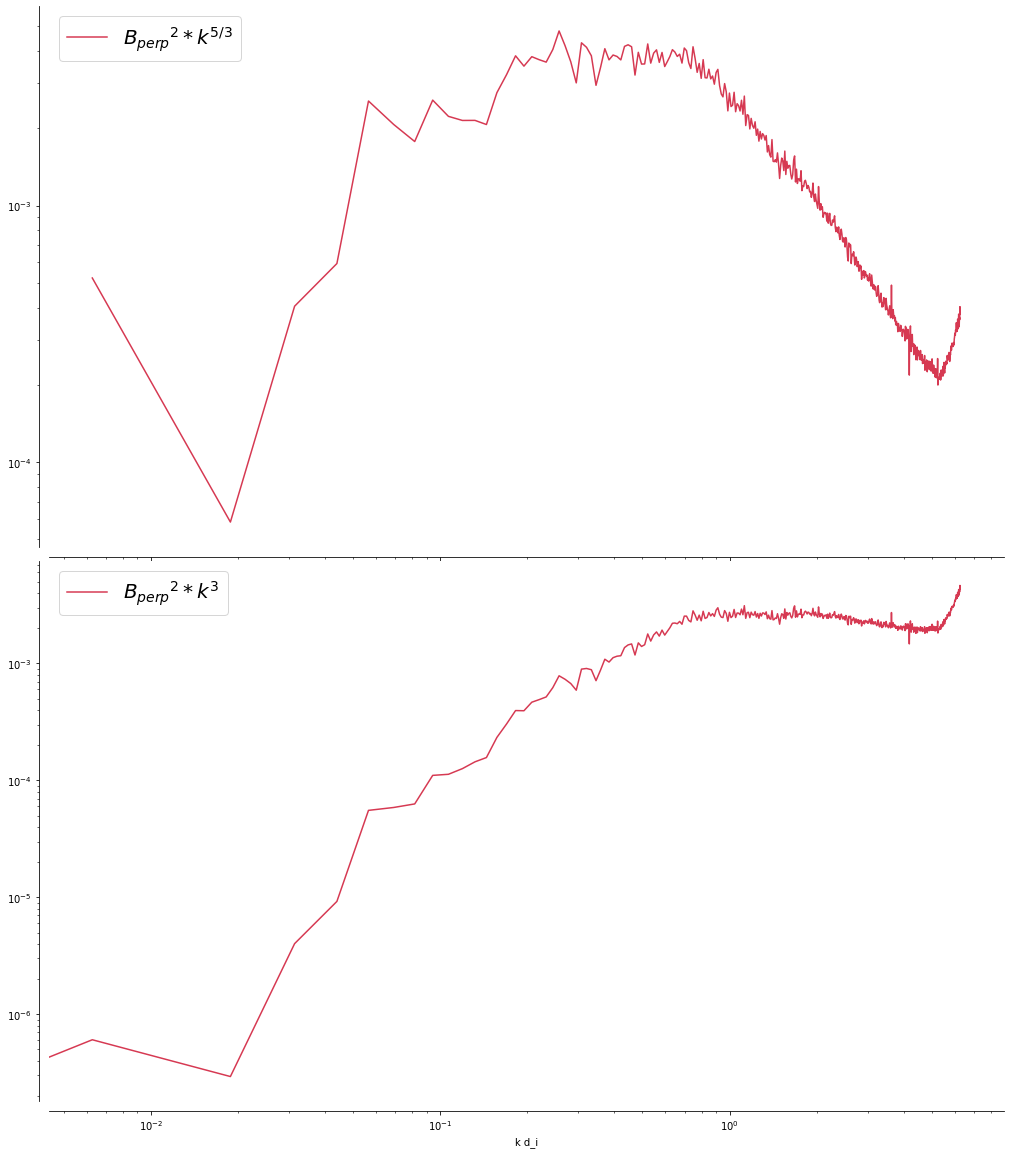

In [11]:
dic = np.load(f'{md_inj.local_path}/spectra.npy', allow_pickle=True).item()
bin_centres = dic['bin_centres']

fig, AX = plt.subplots(2, 1, figsize=(14, 16), sharex=True)

AX[0].plot(bin_centres, dic['B_perp_sqr']*bin_centres**(5/3),  label='${B_{perp}}^2 * k^{5/3}$',  c=oC.rgb[0])
AX[1].plot(bin_centres, dic['B_perp_sqr']*bin_centres**(3),    label='${B_{perp}}^2 * k^3$',  c=oC.rgb[0])

for ax in AX:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(loc=2, fontsize=20)

AX[1].set_xlabel('k d_i')
    
plt.tight_layout()
oT.set_spines(AX)
plt.show()